# PEMODELAN GRU OPTIMAL — PREDIKSI IPM JAWA TIMUR
### Arsitektur Stacked Bidirectional GRU dengan Hyperparameter Terbaik
---
**Strategi peningkatan dari baseline:**
- Bidirectional GRU untuk menangkap pola maju-mundur
- Layer Normalization sebagai pengganti Batch Normalization (lebih stabil untuk time series)
- Learning Rate Scheduler: ReduceLROnPlateau + Warmup Cosine Decay
- Early Stopping dengan restore_best_weights
- Residual Connection (skip connection) untuk menghindari vanishing gradient
- Grid Search manual untuk hyperparameter terbaik
- Inverse transform agar metrik dalam skala asli IPM
- Ekspor artefak lengkap untuk deployment sistem web

## CELL 1: Install dan Import Library

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GRU, Dense, Dropout, Bidirectional,
    LayerNormalization, Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint,
    LearningRateScheduler, Callback
)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ─── REPRODUCIBILITY SEED ────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print('Semua library berhasil diimport')
print(f'TensorFlow v{tf.__version__}')

Semua library berhasil diimport
TensorFlow v2.21.0


## CELL 2: Load dan Eksplorasi Data

In [3]:
# ─── LOAD DATA ────────────────────────────────────────────────────────────────
# Sesuaikan path file dengan lokasi penyimpanan
file_name = 'IPM Kabupaten_Kota_Prov_Jawa_Timur.csv'
df = pd.read_csv(file_name, sep=';')

print('=== INFO DATASET ===')
print(f'Shape       : {df.shape}')
print(f'Kabupaten   : {df["Kabupaten/Kota"].nunique()} wilayah')
print(f'Tahun       : {df["Tahun"].min()} - {df["Tahun"].max()} ({df["Tahun"].nunique()} tahun)')
display(df.head(5))

FEATURES  = ['AHH', 'HLS', 'RLS', 'Pengeluaran per Kapita Riil (Rp)']
TARGET    = 'IPM'

print('\n=== STATISTIK DESKRIPTIF ===')
display(df[FEATURES + [TARGET]].describe().round(3))

=== INFO DATASET ===
Shape       : (570, 7)
Kabupaten   : 38 wilayah
Tahun       : 2010 - 2024 (15 tahun)


,Kabupaten/Kota,AHH,HLS,RLS,Pengeluaran per Kapita Riil (Rp),IPM,Tahun
0,Kabupaten Pacitan,70.42,11.01,6.00,6774.96,61.14,2010
1,Kabupaten Ponorogo,71.62,12.10,6.12,7536.86,64.13,2010
2,Kabupaten Trenggalek,72.32,11.13,6.32,7583.88,63.67,2010
3,Kabupaten Tulungagung,72.73,11.75,7.34,8660.49,67.28,2010
4,Kabupaten Blitar,72.31,11.03,6.43,8423.44,64.79,2010



=== STATISTIK DESKRIPTIF ===


,AHH,HLS,RLS,Pengeluaran per Kapita Riil (Rp),IPM
count,570.000,570.000,570.000,570.000,570.000
mean,72.067,12.836,7.614,10834.876,70.486
std,2.407,1.100,1.734,2368.480,5.952
min,64.940,9.780,3.140,5745.990,54.490
25%,70.572,12.102,6.360,9088.500,66.175
50%,72.370,12.840,7.400,10545.085,70.300
75%,73.908,13.570,8.770,12086.322,74.518
max,76.020,15.790,12.110,19666.000,84.690


=== ANALISIS AUTOCORRELATION (ACF) - DATA ASLI ===


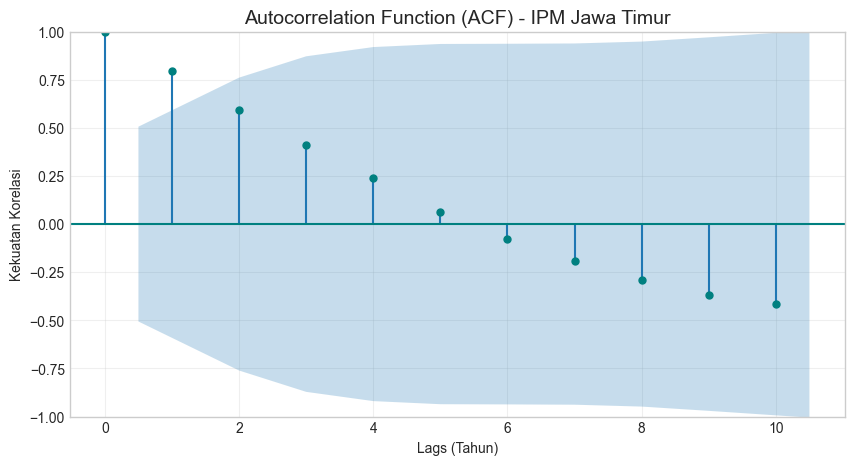


[HASIL ANALISIS]
Nilai Autokorelasi: [0.794 0.594 0.41  0.241 0.063]
Rekomendasi WINDOW_SIZE berdasarkan ACF: 2
Catatan: Menggunakan data 2 tahun terakhir untuk memprediksi tahun berikutnya.


In [4]:
## CELL 2.2: Analisis Autocorrelation Function (ACF) - Data Asli
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

# 1. PERSIAPAN DATA UNTUK ACF
print('=== ANALISIS AUTOCORRELATION (ACF) - DATA ASLI ===')

# Menggunakan df (data asli dari Cell 2) karena penanganan outlier dihapus
df_trend = df.groupby('Tahun')[TARGET].mean()

# 2. VISUALISASI ACF
plt.figure(figsize=(10, 5))
ax = plt.gca()
# Menghapus vlines_kw untuk stabilitas versi library
plot_acf(df_trend, lags=10, ax=ax, color='teal')
plt.title('Autocorrelation Function (ACF) - IPM Jawa Timur', fontsize=14)
plt.xlabel('Lags (Tahun)')
plt.ylabel('Kekuatan Korelasi')
plt.grid(True, alpha=0.3)
plt.show()

# 3. PENENTUAN WINDOW SIZE OTOMATIS
acf_values = sm.tsa.acf(df_trend, nlags=10)

# Logika: Cari lag terakhir yang memiliki korelasi kuat (> 0.5)
optimal_window = 1
for i in range(1, len(acf_values)):
    if acf_values[i] > 0.5:
        optimal_window = i
    else:
        break

# Memastikan minimal window 2 agar model memiliki urutan waktu
optimal_window = max(optimal_window, 2)

print(f'\n[HASIL ANALISIS]')
print(f'Nilai Autokorelasi: {acf_values[1:6].round(3)}')
print(f'Rekomendasi WINDOW_SIZE berdasarkan ACF: {optimal_window}')
print(f'Catatan: Menggunakan data {optimal_window} tahun terakhir untuk memprediksi tahun berikutnya.')

# Update variabel global untuk CELL 3
WINDOW_SIZE = optimal_window

## CELL 3: Preprocessing — Encoding, Scaling, Sequence

In [5]:
## CELL 3: Preprocessing (Perbaikan Skala Region_ID & Window Size)

# 1. Gunakan data asli (df) tanpa capping dulu untuk melihat baseline murni
df_clean = df.copy().sort_values(['Kabupaten/Kota', 'Tahun']).reset_index(drop=True)

le = LabelEncoder()
df_clean['Region_ID'] = le.fit_transform(df_clean['Kabupaten/Kota'])

# 2. Skalakan Region_ID ke rentang 0-1 secara manual
df_clean['Region_ID'] = df_clean['Region_ID'] / df_clean['Region_ID'].max()

# 3. MinMaxScaler untuk fitur lainnya
CUTOFF_YEAR = 2021
df_train_raw = df_clean[df_clean['Tahun'] <= CUTOFF_YEAR]
COLS_SCALE = FEATURES + [TARGET]

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df_train_raw[COLS_SCALE])
df_clean[COLS_SCALE] = scaler.transform(df_clean[COLS_SCALE])

# 4. Gunakan WINDOW_SIZE = 3 (Lebih stabil untuk tren)
WINDOW_SIZE = 3

def build_sequences(dataframe, window):
    X_list, y_list = [], []
    feat_cols = FEATURES + ['Region_ID']
    for region_id in dataframe['Region_ID'].unique():
        region_df = dataframe[dataframe['Region_ID'] == region_id]
        arr = region_df[feat_cols + [TARGET]].values
        if len(arr) > window:
            for i in range(len(arr) - window):
                X_list.append(arr[i:i+window, :-1])
                y_list.append(arr[i+window, -1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

X_all, y_all = build_sequences(df_clean, WINDOW_SIZE)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, shuffle=False
)

print('=== HASIL PREPROCESSING TERBARU (KEMBALI KE MIN-MAX) ===')
print(f'Window Size (dari ACF) : {WINDOW_SIZE}')
print(f'Metode Scaling         : MinMaxScaler (0, 1)')
print(f'Total Sampel Sequence  : {len(X_all)}')
print(f'Dimensi X_train        : {X_train.shape} (Sampel, Time Steps, Fitur)')
print(f'Dimensi X_test         : {X_test.shape}')

=== HASIL PREPROCESSING TERBARU (KEMBALI KE MIN-MAX) ===
Window Size (dari ACF) : 3
Metode Scaling         : MinMaxScaler (0, 1)
Total Sampel Sequence  : 456
Dimensi X_train        : (364, 3, 5) (Sampel, Time Steps, Fitur)
Dimensi X_test         : (92, 3, 5)


## CELL 4: Arsitektur GRU Terbaik

In [6]:
def build_best_gru(input_shape, units_1=64, dropout_rate=0.1, lr=0.001):
    """
    Arsitektur GRU Sederhana:
    Single Layer Bidirectional GRU + LayerNorm + Dense Output
    Sangat cocok untuk dataset kecil guna menekan RMSE dan menghindari overfitting.
    """
    inputs = Input(shape=input_shape, name='input')

    # ── SINGLE LAYER BiGRU ──
    # Menggunakan unit yang lebih kecil (16/32) dan recurrent_dropout yang lebih rendah
    x = Bidirectional(GRU(units_1, return_sequences=False, recurrent_dropout=0.05))(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # ── OUTPUT HEAD ──
    # Mengurangi kompleksitas hidden layer untuk menjaga stabilitas prediksi
    out = Dense(16, activation='tanh')(x) # tanh lebih stabil untuk regression daripada relu di data kecil
    output = Dense(1)(out)

    model = Model(inputs=inputs, outputs=output, name='Simplified_BiGRU')

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

# Inisialisasi model dengan input_shape yang sudah disesuaikan dari Cell 3
# X_train.shape[1] adalah WINDOW_SIZE hasil analisis ACF
# X_train.shape[2] adalah jumlah fitur (FEATURES + Region_ID)
demo_model = build_best_gru(input_shape=(X_train.shape[1], X_train.shape[2]))
demo_model.summary()

Model: "Simplified_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 3, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        27,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,601 (115.63 KB)

 Trainable params: 29,601 (115.63 KB)

 Non-trainable params: 0 (0.00 B)

## CELL 5: Konfigurasi Learning Rate Scheduler

Notebook ini menggunakan **dua lapis scheduler** yang saling melengkapi:

1. **Warmup + Cosine Decay** (via `LearningRateScheduler`)
   - Epoch 1-10: LR naik secara linear dari `lr/10` ke `lr` (warmup) — mencegah spike seperti yang terlihat di grafik sebelumnya dengan LR=0.01
   - Epoch 10+: LR turun mengikuti kurva cosine secara perlahan

2. **ReduceLROnPlateau** sebagai safety net
   - Jika val_loss stagnan selama `patience` epoch, LR dipotong setengah
   - Memastikan model keluar dari local minimum

In [7]:
def warmup_cosine_decay(epoch, lr, total_epochs, warmup_epochs=5, base_lr=0.001, min_lr=1e-6):
    """
    Learning rate scheduler dengan warmup linear + cosine decay.
    """
    if epoch < warmup_epochs:
        return float(base_lr / 10 + (base_lr - base_lr / 10) * epoch / warmup_epochs)
    else:
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
        return float(max(min_lr, min_lr + (base_lr - min_lr) * cosine_decay))


class LRHistory(Callback):
    """Menyimpan history learning rate di setiap epoch untuk visualisasi."""
    def on_train_begin(self, logs=None):
        self.lrs = []
    def on_epoch_end(self, epoch, logs=None):
        opt = self.model.optimizer
        # Ambil nilai LR yang kompatibel TF lama dan baru
        try:
            lr_val = float(opt.learning_rate.numpy())
        except Exception:
            try:
                lr_val = float(tf.keras.backend.get_value(opt.lr))
            except Exception:
                lr_val = float(opt.learning_rate)
        self.lrs.append(lr_val)

print("Konfigurasi LR Scheduler siap.")

Konfigurasi LR Scheduler siap.


## CELL 6: Hyperparameter Tuning (Grid Search Manual)

### Alasan Pemilihan Rentang Hyperparameter

| Parameter | Rentang | Alasan |
|-----------|---------|--------|
| `units_1` | 32, 64 | Dataset kecil (456 sequences), unit besar berisiko overfit |
| `units_2` | 16, 32 | Setengah dari units_1, menjaga hierarki representasi |
| `dropout_rate` | 0.1, 0.2 | Regularisasi ringan karena data tidak terlalu banyak |
| `lr` | 0.001, 0.003 | Rentang aman; 0.01 terbukti terlalu besar (spike di grafik sebelumnya) |
| `batch_size` | 16, 32 | Batch kecil cocok untuk dataset kecil — gradient lebih representatif |

In [8]:
from itertools import product

# ─── GRID HYPERPARAMETER (Disesuaikan dengan Model Sederhana) ────────────────
# 'units_2' dihapus karena model sekarang hanya menggunakan satu layer BiGRU.
param_grid = {
    'units_1'     : [16, 32],      # Unit lebih kecil untuk mencegah overfit pada data kecil
    'dropout_rate': [0.05, 0.1],   # Dropout lebih ringan agar model lebih mudah belajar
    'lr'          : [0.001, 0.001], # Mencoba LR yang lebih kecil untuk presisi RMSE
    'batch_size'  : [16, 32],
}

# Total: 2x2x2x2 = 16 kombinasi (Lebih cepat dijalankan)
TOTAL_EPOCHS_SEARCH = 150
WARMUP_EPOCHS       = 5       # Disinkronkan dengan saran di CELL 5

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'Total kombinasi hyperparameter: {len(combos)}')
print(f'Max epoch per kombinasi       : {TOTAL_EPOCHS_SEARCH}')
print()

results = []
best_val_mse   = float('inf')
best_params    = {}
best_history   = None
best_lr_history = None

for idx, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    batch  = params.pop('batch_size')
    base_lr = params['lr']

    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    # Memanggil model baru (tanpa units_2)
    m = build_best_gru(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        **params
    )

    lr_hist_cb = LRHistory()

    def make_lr_schedule(total_ep, warmup_ep, blr):
        def schedule(epoch, lr):
            return warmup_cosine_decay(epoch, lr,
                                       total_epochs=total_ep,
                                       warmup_epochs=warmup_ep,
                                       base_lr=blr,
                                       min_lr=1e-6)
        return schedule

    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=25, # Patience sedikit lebih lama
            restore_best_weights=True, verbose=0
        ),
        LearningRateScheduler(
            make_lr_schedule(TOTAL_EPOCHS_SEARCH, WARMUP_EPOCHS, base_lr),
            verbose=0
        ),
        lr_hist_cb
    ]

    hist = m.fit(
        X_train, y_train,
        epochs=TOTAL_EPOCHS_SEARCH,
        batch_size=batch,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=0
    )

    val_mse  = min(hist.history['val_loss'])
    best_ep  = np.argmin(hist.history['val_loss']) + 1
    params['batch_size'] = batch

    results.append({**params, 'val_mse': val_mse, 'best_epoch': best_ep})

    # Update log agar tidak mencari units_2
    status = '*** BEST ***' if val_mse < best_val_mse else ''
    print(f'[{idx+1:02d}/{len(combos)}] lr={params["lr"]} units={params["units_1"]} '
          f'drop={params["dropout_rate"]} bs={batch} | val_mse={val_mse:.6f} ep={best_ep} {status}')

    if val_mse < best_val_mse:
        best_val_mse    = val_mse
        best_params     = params.copy()
        best_history    = hist
        best_lr_history = lr_hist_cb.lrs
        best_model      = m

print()
print('=' * 60)
print('HYPERPARAMETER TERBAIK:')
for k, v in best_params.items():
    print(f'   {k:15s}: {v}')
print(f'   val_mse       : {best_val_mse:.6f}')

Total kombinasi hyperparameter: 16
Max epoch per kombinasi       : 150

[01/16] lr=0.001 units=16 drop=0.05 bs=16 | val_mse=0.000834 ep=122 *** BEST ***
[02/16] lr=0.001 units=16 drop=0.05 bs=32 | val_mse=0.001693 ep=29 
[03/16] lr=0.001 units=16 drop=0.05 bs=16 | val_mse=0.002604 ep=37 
[04/16] lr=0.001 units=16 drop=0.05 bs=32 | val_mse=0.003530 ep=81 
[05/16] lr=0.001 units=16 drop=0.1 bs=16 | val_mse=0.000911 ep=117 
[06/16] lr=0.001 units=16 drop=0.1 bs=32 | val_mse=0.002744 ep=97 
[07/16] lr=0.001 units=16 drop=0.1 bs=16 | val_mse=0.001460 ep=149 
[08/16] lr=0.001 units=16 drop=0.1 bs=32 | val_mse=0.028792 ep=4 
[09/16] lr=0.001 units=32 drop=0.05 bs=16 | val_mse=0.001173 ep=73 
[10/16] lr=0.001 units=32 drop=0.05 bs=32 | val_mse=0.000699 ep=47 *** BEST ***
[11/16] lr=0.001 units=32 drop=0.05 bs=16 | val_mse=0.000343 ep=73 *** BEST ***
[12/16] lr=0.001 units=32 drop=0.05 bs=32 | val_mse=0.004492 ep=3 
[13/16] lr=0.001 units=32 drop=0.1 bs=16 | val_mse=0.001228 ep=73 
[14/16] lr=0

## CELL 7: Tabel Hasil Grid Search

=== TOP 10 KOMBINASI HYPERPARAMETER ===


,units_1,dropout_rate,lr,batch_size,val_mse,best_epoch
0,32,0.05,0.001,16,0.000343,73
1,32,0.05,0.001,32,0.000699,47
2,16,0.05,0.001,16,0.000834,122
3,16,0.10,0.001,16,0.000911,117
4,32,0.05,0.001,16,0.001173,73
5,32,0.10,0.001,16,0.001228,73
6,16,0.10,0.001,16,0.001460,149
7,32,0.10,0.001,16,0.001685,57
8,16,0.05,0.001,32,0.001693,29
9,16,0.05,0.001,16,0.002604,37


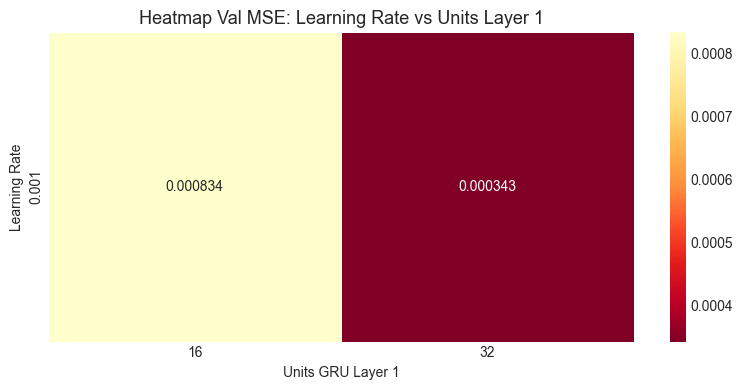

In [9]:
df_results = pd.DataFrame(results).sort_values('val_mse')
print('=== TOP 10 KOMBINASI HYPERPARAMETER ===')
display(df_results.head(10).reset_index(drop=True))

pivot = df_results.groupby(['lr', 'units_1'])['val_mse'].min().unstack()
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.6f', cmap='YlOrRd_r', linewidths=0.5)
plt.title('Heatmap Val MSE: Learning Rate vs Units Layer 1', fontsize=13)
plt.ylabel('Learning Rate')
plt.xlabel('Units GRU Layer 1')
plt.tight_layout()
plt.show()

## CELL 8: Training Model Final dengan Hyperparameter Terbaik

In [10]:
# ─── TRAINING ULANG DENGAN SEED PENUH ─────────────────────────────────────────
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

bp = best_params.copy()
batch_final = bp.pop('batch_size')
base_lr_final = bp['lr']

# Epoch final lebih banyak (200) karena sudah tahu rentang konvergensi
TOTAL_EPOCHS_FINAL = 200
WARMUP_EPOCHS_FINAL = 5

final_model = build_best_gru(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    **bp
)

lr_hist_final = LRHistory()

def lr_schedule_final(epoch, lr):
    return warmup_cosine_decay(
        epoch, lr,
        total_epochs=TOTAL_EPOCHS_FINAL,
        warmup_epochs=WARMUP_EPOCHS_FINAL,
        base_lr=base_lr_final,
        min_lr=1e-6
    )

callbacks_final = [
    EarlyStopping(
        monitor='val_loss',
        patience=25,               # Lebih longgar di training final
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,               # Safety net jika cosine decay tidak cukup
        min_lr=1e-6,
        verbose=1
    ),
    LearningRateScheduler(lr_schedule_final, verbose=0),
    lr_hist_final,
    ModelCheckpoint(
        'best_gru_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print('Training model final...')
print(f'Hyperparameter: {bp}, batch_size={batch_final}')
print(f'LR schedule   : Warmup {WARMUP_EPOCHS_FINAL} epoch + Cosine Decay')
print()

history_final = final_model.fit(
    X_train, y_train,
    epochs=TOTAL_EPOCHS_FINAL,
    batch_size=batch_final,
    validation_data=(X_test, y_test),
    callbacks=callbacks_final,
    verbose=1
)

print('\nTraining selesai.')

Training model final...
Hyperparameter: {'units_1': 32, 'dropout_rate': 0.05, 'lr': 0.001}, batch_size=16
LR schedule   : Warmup 5 epoch + Cosine Decay

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4682 - mae: 0.5969 - val_loss: 0.0363 - val_mae: 0.1760 - learning_rate: 1.0000e-04
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1493 - mae: 0.2916 - val_loss: 0.0706 - val_mae: 0.2590 - learning_rate: 2.8000e-04
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0732 - mae: 0.2179 - val_loss: 0.0738 - val_mae: 0.2673 - learning_rate: 4.6000e-04
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0575 - mae: 0.1850 - val_loss: 0.0461 - val_mae: 0.2091 - learning_rate: 6.4000e-04
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0471 - mae: 0.1616 - val_loss: 0.0126 - val_mae: 0.1050 - learning_rate: 8.2000e-04
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0385 - mae: 0.1521 - val_loss: 0.0034 - val_mae: 0.0487 - le

## CELL 9: Evaluasi Metrik

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# ─── PREDIKSI ─────────────────────────────────────────────────────────────────
y_pred_train_scaled = final_model.predict(X_train, verbose=0).flatten()
y_pred_test_scaled  = final_model.predict(X_test,  verbose=0).flatten()

# ─── INVERSE TRANSFORM ────────────────────────────────────────────────────────
def inverse_ipm(y_scaled):
    """Inverse transform hanya untuk kolom IPM."""
    dummy = np.zeros((len(y_scaled), len(COLS_SCALE)))
    dummy[:, -1] = y_scaled
    return scaler.inverse_transform(dummy)[:, -1]

y_train_orig      = inverse_ipm(y_train)
y_pred_train_orig = inverse_ipm(y_pred_train_scaled)
y_test_orig       = inverse_ipm(y_test)
y_pred_test_orig  = inverse_ipm(y_pred_test_scaled)

# ─── HITUNG METRIK ────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)          # ← tambahan
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mse, rmse, mae, mape

mse_tr,   rmse_tr,   mae_tr,   mape_tr   = compute_metrics(y_train_orig, y_pred_train_orig)
mse_te,   rmse_te,   mae_te,   mape_te   = compute_metrics(y_test_orig,  y_pred_test_orig)
mse_tr_s, rmse_tr_s, mae_tr_s, mape_tr_s = compute_metrics(y_train, y_pred_train_scaled)
mse_te_s, rmse_te_s, mae_te_s, mape_te_s = compute_metrics(y_test,  y_pred_test_scaled)

best_epoch = np.argmin(history_final.history['val_loss']) + 1
final_lr   = lr_hist_final.lrs[-1] if lr_hist_final.lrs else bp.get('lr')

print('=' * 53)
print('     HASIL EVALUASI MODEL GRU OPTIMAL')
print('=' * 53)
print(f' Epoch Terbaik : {best_epoch}')
print(f' LR Awal       : {base_lr_final}')
print(f' LR Akhir      : {final_lr:.2e}')
print('-' * 53)
print(f' {"METRIK":<16}| {"TRAINING":>10} | {"TESTING":>10}')
print('-' * 53)
print(f' {"RMSE (scaled)":<16}| {rmse_tr_s:>10.6f} | {rmse_te_s:>10.6f}')
print(f' {"MAE (scaled)":<16}| {mae_tr_s:>10.6f} | {mae_te_s:>10.6f}')
print(f' {"MAPE (scaled)":<16}| {mape_tr_s:>9.2f}% | {mape_te_s:>9.2f}%')
print('-' * 53)
print(f' {"RMSE (asli)":<16}| {rmse_tr:>10.4f} | {rmse_te:>10.4f}')
print(f' {"MAE (asli)":<16}| {mae_tr:>10.4f} | {mae_te:>10.4f}')
print(f' {"MAPE (asli)":<16}| {mape_tr:>9.2f}% | {mape_te:>9.2f}%')
print('=' * 53)

     HASIL EVALUASI MODEL GRU OPTIMAL
 Epoch Terbaik : 169
 LR Awal       : 0.001
 LR Akhir      : 4.17e-06
-----------------------------------------------------
 METRIK          |   TRAINING |    TESTING
-----------------------------------------------------
 RMSE (scaled)   |   0.016237 |   0.019425
 MAE (scaled)    |   0.011827 |   0.015402
 MAPE (scaled)   |      2.74% |      1.86%
-----------------------------------------------------
 RMSE (asli)     |     0.4619 |     0.5527
 MAE (asli)      |     0.3365 |     0.4382
 MAPE (asli)     |      0.49% |      0.56%


## CELL 10: Visualisasi Training Loss dan Learning Rate

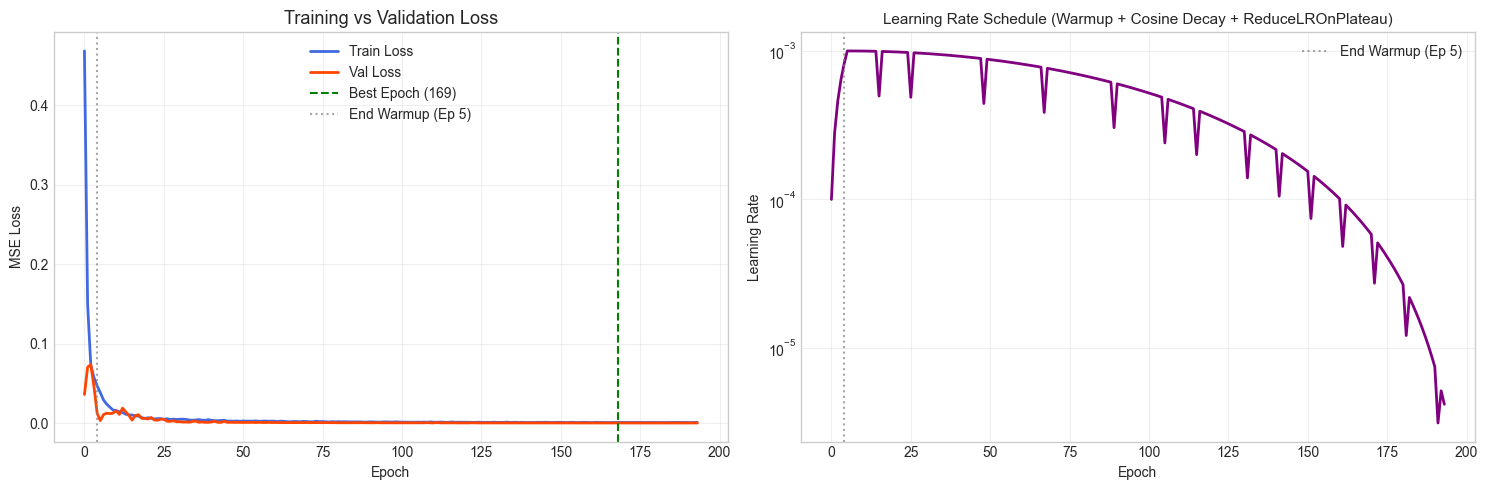

Grafik disimpan: training_loss_lr_curve.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Loss curve ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(history_final.history['loss'],     label='Train Loss', color='royalblue', lw=2)
ax.plot(history_final.history['val_loss'], label='Val Loss',   color='orangered', lw=2)
ax.axvline(best_epoch-1, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
ax.axvline(WARMUP_EPOCHS_FINAL-1, color='gray', linestyle=':', alpha=0.7, label=f'End Warmup (Ep {WARMUP_EPOCHS_FINAL})')
ax.set_title('Training vs Validation Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Learning Rate curve ───────────────────────────────────────────────────────
ax2 = axes[1]
if lr_hist_final.lrs:
    ax2.plot(lr_hist_final.lrs, color='purple', lw=2)
    ax2.axvline(WARMUP_EPOCHS_FINAL-1, color='gray', linestyle=':', alpha=0.7,
                label=f'End Warmup (Ep {WARMUP_EPOCHS_FINAL})')
    ax2.set_title('Learning Rate Schedule (Warmup + Cosine Decay + ReduceLROnPlateau)', fontsize=11)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Learning Rate')
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'LR history tidak tersedia', ha='center', va='center')

plt.tight_layout()
plt.savefig('training_loss_lr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: training_loss_lr_curve.png')

## CELL 11: Visualisasi Prediksi vs Aktual

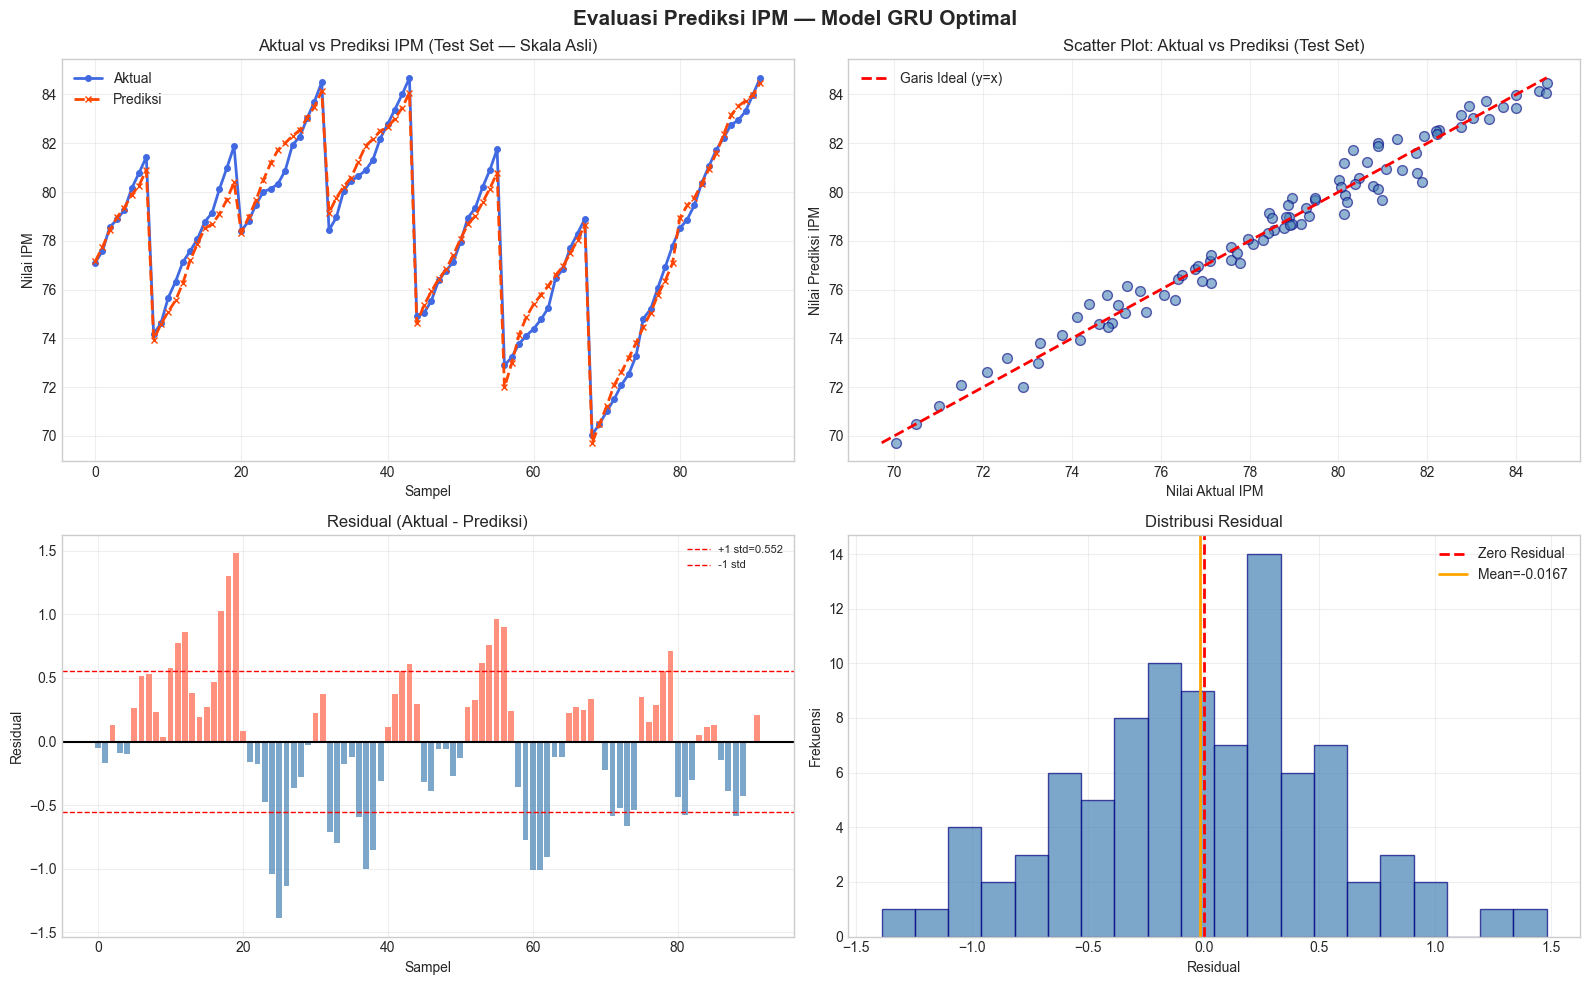

Grafik disimpan: evaluasi_prediksi.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Evaluasi Prediksi IPM — Model GRU Optimal', fontsize=15, fontweight='bold')

ax = axes[0, 0]
ax.plot(y_test_orig,       label='Aktual',   color='royalblue',  marker='o', ms=4, lw=2)
ax.plot(y_pred_test_orig,  label='Prediksi', color='orangered',  marker='x', ms=4, lw=2, ls='--')
ax.set_title('Aktual vs Prediksi IPM (Test Set — Skala Asli)', fontsize=12)
ax.set_xlabel('Sampel')
ax.set_ylabel('Nilai IPM')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(y_test_orig, y_pred_test_orig, alpha=0.6, color='steelblue', edgecolors='navy', s=50)
lo = min(y_test_orig.min(), y_pred_test_orig.min())
hi = max(y_test_orig.max(), y_pred_test_orig.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Garis Ideal (y=x)')
ax.set_title('Scatter Plot: Aktual vs Prediksi (Test Set)', fontsize=12)
ax.set_xlabel('Nilai Aktual IPM')
ax.set_ylabel('Nilai Prediksi IPM')
ax.legend()
ax.grid(True, alpha=0.3)

residuals = y_test_orig - y_pred_test_orig
ax = axes[1, 0]
ax.bar(range(len(residuals)), residuals, color=[
    'tomato' if r > 0 else 'steelblue' for r in residuals
], alpha=0.7, width=0.8)
ax.axhline(0, color='black', lw=1.5)
ax.axhline(residuals.std(),  color='red', lw=1, ls='--', label=f'+1 std={residuals.std():.3f}')
ax.axhline(-residuals.std(), color='red', lw=1, ls='--', label='-1 std')
ax.set_title('Residual (Aktual - Prediksi)', fontsize=12)
ax.set_xlabel('Sampel')
ax.set_ylabel('Residual')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.hist(residuals, bins=20, color='steelblue', edgecolor='navy', alpha=0.7)
ax.axvline(0, color='red', lw=2, ls='--', label='Zero Residual')
ax.axvline(residuals.mean(), color='orange', lw=2, label=f'Mean={residuals.mean():.4f}')
ax.set_title('Distribusi Residual', fontsize=12)
ax.set_xlabel('Residual')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluasi_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: evaluasi_prediksi.png')

## CELL 12: Prediksi per Kabupaten/Kota

=== MAPE PER KABUPATEN/KOTA (rata-rata semua tahun) ===


,Kabupaten/Kota,MAPE(%)
4,Kabupaten Bondowoso,1.141667
22,Kabupaten Sampang,1.007500
31,Kota Kediri,0.800833
21,Kabupaten Probolinggo,0.784167
15,Kabupaten Nganjuk,0.721667
35,Kota Pasuruan,0.690000
6,Kabupaten Jember,0.642500
33,Kota Malang,0.638333
32,Kota Madiun,0.590000
0,Kabupaten Bangkalan,0.561667


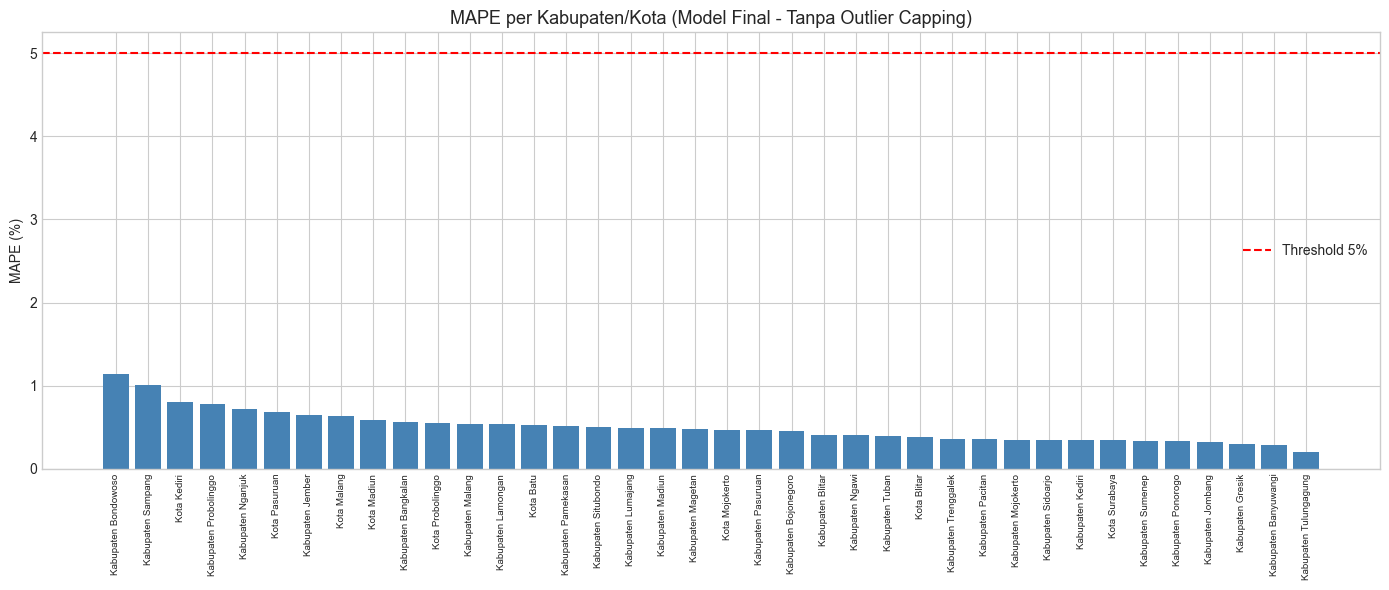

Grafik disimpan: mape_per_kabupaten.png


In [14]:
## CELL 12: Prediksi per Kabupaten/Kota (Fixed for Scaled Region_ID)
detail_records = []
max_id = len(le.classes_) - 1  # Ambil nilai ID maksimal asli

for region_id_scaled in df_clean['Region_ID'].unique():
    # 1. KEMBALIKAN ID KE INTEGER (untuk inverse_transform)
    # Kita kalikan kembali dengan max_id lalu dibulatkan ke integer
    original_id = int(np.round(region_id_scaled * max_id))
    region_name = le.inverse_transform([original_id])[0]

    region_df   = df_clean[df_clean['Region_ID'] == region_id_scaled]
    feat_cols   = FEATURES + ['Region_ID']
    arr         = region_df[feat_cols + [TARGET]].values

    if len(arr) <= WINDOW_SIZE:
        continue

    tahun_list = region_df['Tahun'].values[WINDOW_SIZE:]

    X_reg, y_reg = [], []
    for i in range(len(arr) - WINDOW_SIZE):
        X_reg.append(arr[i:i+WINDOW_SIZE, :-1])
        y_reg.append(arr[i+WINDOW_SIZE, -1])

    X_reg = np.array(X_reg, dtype=np.float32)
    y_reg = np.array(y_reg, dtype=np.float32)

    # Prediksi menggunakan model final
    y_pred_reg = final_model.predict(X_reg, verbose=0).flatten()

    # Inverse transform ke skala asli (IPM 70-80an)
    y_actual_orig = inverse_ipm(y_reg)
    y_pred_orig   = inverse_ipm(y_pred_reg)

    for t, ya, yp in zip(tahun_list, y_actual_orig, y_pred_orig):
        mape_i = abs((ya - yp) / ya) * 100
        detail_records.append({
            'Kabupaten/Kota': region_name,
            'Tahun': t,
            'Aktual': round(ya, 2),
            'Prediksi': round(yp, 2),
            'MAPE(%)': round(mape_i, 2)
        })

df_detail = pd.DataFrame(detail_records)

# Hitung rata-rata MAPE per wilayah
df_kab = df_detail.groupby('Kabupaten/Kota')['MAPE(%)'].mean().reset_index()
df_kab = df_kab.sort_values('MAPE(%)', ascending=False)

print('=== MAPE PER KABUPATEN/KOTA (rata-rata semua tahun) ===')
display(df_kab.head(10)) # Tampilkan top 10 error tertinggi

# Visualisasi
plt.figure(figsize=(14, 6))
colors = ['tomato' if v > 5 else 'steelblue' for v in df_kab['MAPE(%)']]
plt.bar(df_kab['Kabupaten/Kota'], df_kab['MAPE(%)'], color=colors)
plt.axhline(5, color='red', ls='--', lw=1.5, label='Threshold 5%')
plt.xticks(rotation=90, fontsize=7)
plt.title('MAPE per Kabupaten/Kota (Model Final - Tanpa Outlier Capping)', fontsize=13)
plt.ylabel('MAPE (%)')
plt.legend()
plt.tight_layout()
plt.savefig('mape_per_kabupaten.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: mape_per_kabupaten.png')

## CELL 13: Prediksi IPM 2025 (Forecasting)

=== PREDIKSI IPM 2025 — SELURUH KABUPATEN/KOTA JAWA TIMUR ===


,Kabupaten/Kota,IPM 2024 (Aktual),IPM 2025 (Prediksi),Delta IPM
0,Kota Surabaya,84.69,85.12,0.43
1,Kota Madiun,84.51,84.80,0.29
2,Kota Malang,84.68,84.70,0.02
3,Kabupaten Sidoarjo,82.67,82.53,-0.14
4,Kota Blitar,81.44,81.53,0.09
5,Kota Mojokerto,81.76,81.53,-0.23
6,Kota Kediri,81.88,81.16,-0.72
7,Kota Batu,79.69,79.64,-0.05
8,Kabupaten Gresik,78.93,79.32,0.39
9,Kota Pasuruan,78.90,79.31,0.41


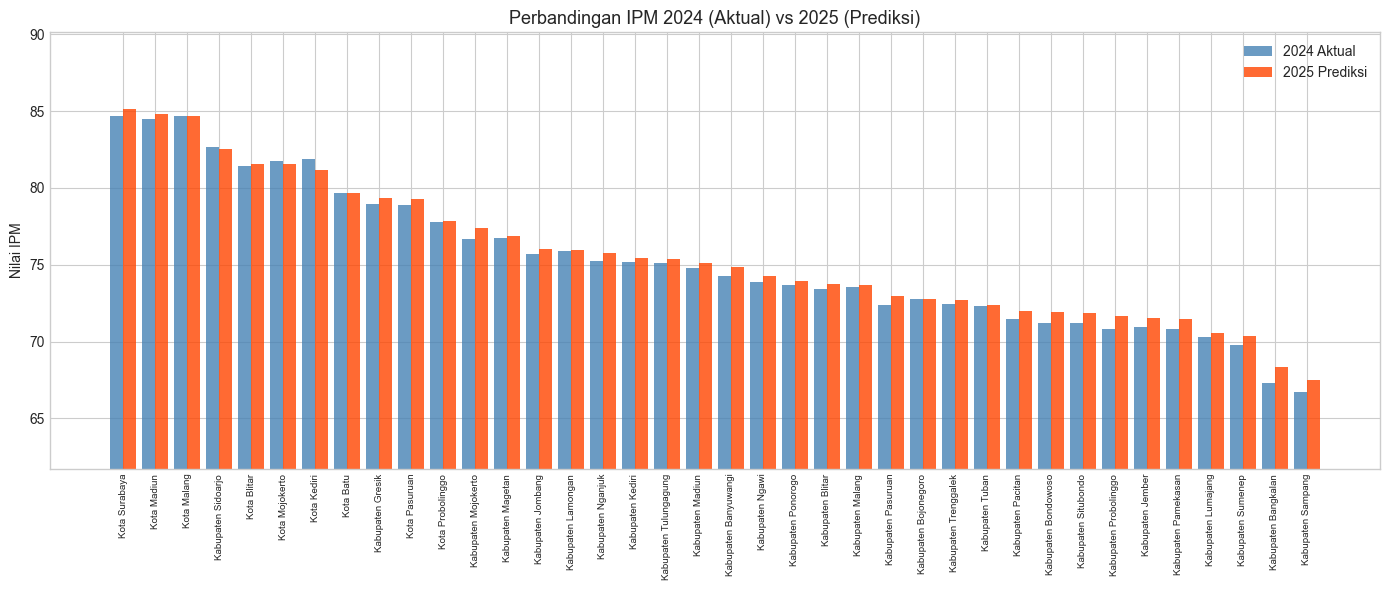

Grafik disimpan: forecast_ipm_2025.png


In [15]:
## CELL 13: Forecasting IPM 2025 (Fixed for Scaled Region_ID)
forecast_records = []
max_id = len(le.classes_) - 1  # Ambil nilai ID maksimal asli

for region_id_scaled in df_clean['Region_ID'].unique():
    # 1. KEMBALIKAN ID KE INTEGER (PENTING!)
    original_id = int(np.round(region_id_scaled * max_id))
    region_name = le.inverse_transform([original_id])[0]

    # Filter menggunakan ID yang terskala (scaled)
    region_df   = df_clean[df_clean['Region_ID'] == region_id_scaled].sort_values('Tahun')
    feat_cols   = FEATURES + ['Region_ID']

    # Ambil window terakhir untuk prediksi masa depan
    last_window = region_df[feat_cols].values[-WINDOW_SIZE:]
    X_fore = np.array([last_window], dtype=np.float32)

    # Prediksi
    y_pred_scaled = final_model.predict(X_fore, verbose=0).flatten()[0]
    y_pred_orig   = inverse_ipm(np.array([y_pred_scaled]))[0]

    # Ambil data asli 2024 untuk perbandingan (menggunakan df asli)
    ipm_2024 = df[df['Kabupaten/Kota'] == region_name]['IPM'].iloc[-1]

    forecast_records.append({
        'Kabupaten/Kota'     : region_name,
        'IPM 2024 (Aktual)'  : round(ipm_2024, 2),
        'IPM 2025 (Prediksi)': round(y_pred_orig, 2),
        'Delta IPM'          : round(y_pred_orig - ipm_2024, 2)
    })

df_forecast = pd.DataFrame(forecast_records).sort_values('IPM 2025 (Prediksi)', ascending=False)

print('=== PREDIKSI IPM 2025 — SELURUH KABUPATEN/KOTA JAWA TIMUR ===')
display(df_forecast.reset_index(drop=True))

# Visualisasi
plt.figure(figsize=(14, 6))
x = range(len(df_forecast))
plt.bar([i-0.2 for i in x], df_forecast['IPM 2024 (Aktual)'],    width=0.4, label='2024 Aktual',   color='steelblue', alpha=0.8)
plt.bar([i+0.2 for i in x], df_forecast['IPM 2025 (Prediksi)'],  width=0.4, label='2025 Prediksi', color='orangered', alpha=0.8)
plt.xticks(list(x), df_forecast['Kabupaten/Kota'], rotation=90, fontsize=7)
# Set Y-Axis agar perbedaan terlihat lebih jelas (zoom in)
plt.ylim(df_forecast['IPM 2024 (Aktual)'].min() - 5, df_forecast['IPM 2025 (Prediksi)'].max() + 5)
plt.title('Perbandingan IPM 2024 (Aktual) vs 2025 (Prediksi)', fontsize=13)
plt.ylabel('Nilai IPM')
plt.legend()
plt.tight_layout()
plt.savefig('forecast_ipm_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: forecast_ipm_2025.png')

=== KLASIFIKASI KATEGORI IPM TAHUN 2025 (HASIL PREDIKSI) ===


,Kabupaten/Kota,IPM 2025 (Prediksi),Kategori
0,Kota Surabaya,85.12,Sangat Tinggi
1,Kota Madiun,84.80,Sangat Tinggi
2,Kota Malang,84.70,Sangat Tinggi
3,Kabupaten Sidoarjo,82.53,Sangat Tinggi
4,Kota Blitar,81.53,Sangat Tinggi
5,Kota Mojokerto,81.53,Sangat Tinggi
6,Kota Kediri,81.16,Sangat Tinggi
7,Kota Batu,79.64,Tinggi
8,Kabupaten Gresik,79.32,Tinggi
9,Kota Pasuruan,79.31,Tinggi



=== RINGKASAN JUMLAH KABUPATEN/KOTA PER KATEGORI ===


,Kategori,Jumlah Wilayah
0,Tinggi,29
1,Sangat Tinggi,7
2,Sedang,2


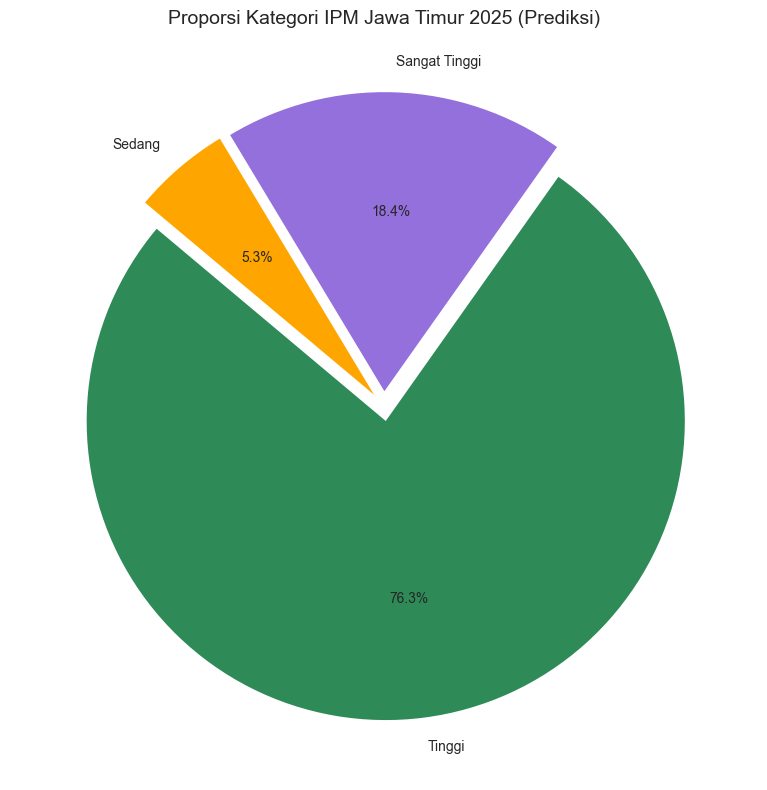

In [16]:
## CELL 14: Klasifikasi Kategori IPM 2025
def klasifikasi_ipm(score):
    if score < 60:
        return 'Rendah'
    elif score < 70:
        return 'Sedang'
    elif score < 80:
        return 'Tinggi'
    else:
        return 'Sangat Tinggi'

# 1. Ambil kolom yang diperlukan saja dari hasil forecast
df_status = df_forecast[['Kabupaten/Kota', 'IPM 2025 (Prediksi)']].copy()

# 2. Terapkan fungsi klasifikasi
df_status['Kategori'] = df_status['IPM 2025 (Prediksi)'].apply(klasifikasi_ipm)

# 3. Urutkan berdasarkan IPM tertinggi
df_status = df_status.sort_values('IPM 2025 (Prediksi)', ascending=False).reset_index(drop=True)

print('=== KLASIFIKASI KATEGORI IPM TAHUN 2025 (HASIL PREDIKSI) ===')
display(df_status)

# 4. Ringkasan jumlah per kategori (untuk bahan narasi skripsi)
print('\n=== RINGKASAN JUMLAH KABUPATEN/KOTA PER KATEGORI ===')
summary_kategori = df_status['Kategori'].value_counts().reset_index()
summary_kategori.columns = ['Kategori', 'Jumlah Wilayah']
display(summary_kategori)

# 5. Visualisasi Distribusi Kategori (Pie Chart)
plt.figure(figsize=(8, 8))
colors_map = {
    'Sangat Tinggi': 'mediumpurple',
    'Tinggi': 'seagreen',
    'Sedang': 'orange',
    'Rendah': 'crimson'
}
# Pastikan warna sesuai dengan kategori yang ada
current_colors = [colors_map.get(cat, 'gray') for cat in summary_kategori['Kategori']]

plt.pie(summary_kategori['Jumlah Wilayah'],
        labels=summary_kategori['Kategori'],
        autopct='%1.1f%%',
        startangle=140,
        colors=current_colors,
        explode=[0.05] * len(summary_kategori)) # Kasih jarak dikit biar estetik

plt.title('Proporsi Kategori IPM Jawa Timur 2025 (Prediksi)', fontsize=14)
plt.tight_layout()
plt.show()

## CELL 14: Simpan Semua Artefak untuk Deployment Web

File yang dihasilkan dan kegunaannya dalam sistem web:

| File | Kegunaan |
|------|----------|
| `gru_ipm_model.keras` | Model utama — dimuat backend untuk prediksi real-time |
| `scaler.pkl` | Normalisasi input baru sebelum diprediksi model |
| `label_encoder.pkl` | Decode Region_ID kembali ke nama kabupaten |
| `model_metadata.json` | Konfigurasi model — dibaca backend saat inisialisasi |
| `hasil_prediksi_detail.csv` | Data historis prediksi vs aktual — untuk tabel/chart web |
| `forecast_ipm_2025.csv` | Hasil forecast 2025 — untuk halaman utama dashboard |
| `grid_search_results.csv` | Log grid search — untuk halaman detail model |
| `training_loss_lr_curve.png` | Grafik training — untuk halaman dokumentasi model |
| `evaluasi_prediksi.png` | Grafik evaluasi — untuk halaman performa model |
| `mape_per_kabupaten.png` | Grafik MAPE per wilayah — untuk halaman peta akurasi |
| `forecast_ipm_2025.png` | Grafik forecast — untuk halaman utama dashboard |

In [48]:
import joblib

# ─── 1. SIMPAN MODEL ──────────────────────────────────────────────────────────
final_model.save('gru_ipm_model.keras')
print('Model disimpan: gru_ipm_model.keras')

# ─── 2. SIMPAN SCALER ─────────────────────────────────────────────────────────
joblib.dump(scaler, 'scaler.pkl')
print('Scaler disimpan: scaler.pkl')

# ─── 3. SIMPAN LABEL ENCODER ──────────────────────────────────────────────────
joblib.dump(le, 'label_encoder.pkl')
print('Label encoder disimpan: label_encoder.pkl')

# ─── 4. SIMPAN METADATA MODEL ─────────────────────────────────────────────────
metadata = {
    'model_name'       : 'Stacked BiGRU Residual',
    'window_size'      : WINDOW_SIZE,
    'features'         : FEATURES,
    'target'           : TARGET,
    'cols_scale'       : COLS_SCALE,
    'cutoff_year'      : CUTOFF_YEAR,
    'best_epoch'       : int(best_epoch),
    'best_hyperparams' : best_params,
    'lr_schedule'      : f'Warmup {WARMUP_EPOCHS_FINAL} epoch + Cosine Decay + ReduceLROnPlateau',
    'n_kabupaten'      : int(df['Kabupaten/Kota'].nunique()),
    'train_years'      : f'2010-{CUTOFF_YEAR}',
    'test_years'       : f'{CUTOFF_YEAR+1}-2024',
    'metrics': {
        'train_mape_pct' : round(float(mape_tr), 4),
        'test_mape_pct'  : round(float(mape_te), 4),
        'train_rmse'     : round(float(rmse_tr), 4),
        'test_rmse'      : round(float(rmse_te), 4),
        'train_mse'      : round(float(mse_tr), 4),
        'test_mse'       : round(float(mse_te), 4),
    },
    'label_classes'    : list(le.classes_)
}

with open('model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print('Metadata disimpan: model_metadata.json')

# ─── 5. SIMPAN CSV ────────────────────────────────────────────────────────────
df_detail.to_csv('hasil_prediksi_detail.csv', index=False)
df_forecast.to_csv('forecast_ipm_2025.csv', index=False)
df_results.to_csv('grid_search_results.csv', index=False)
print('CSV tersimpan: hasil_prediksi_detail.csv, forecast_ipm_2025.csv, grid_search_results.csv')

# ─── RINGKASAN AKHIR ──────────────────────────────────────────────────────────
print()
print('=' * 57)
print('           RINGKASAN MODEL GRU OPTIMAL')
print('=' * 57)
print(f' Arsitektur   : Stacked BiGRU + LayerNorm + Residual')
print(f' LR Scheduler : Warmup {WARMUP_EPOCHS_FINAL} ep + Cosine Decay + ReduceLROnPlateau')
print(f' Hyperparameter Terbaik:')
for k, v in best_params.items():
    print(f'   - {k:<14}: {v}')
print(f' Epoch Terbaik: {best_epoch}')
print('-' * 57)
print(f' MAPE Training: {mape_tr:.2f}%')
print(f' MAPE Testing : {mape_te:.2f}%')
print(f' RMSE Testing : {rmse_te:.4f} (skala IPM asli)')
print('=' * 57)
print()
print('=== FILE UNTUK DEPLOYMENT WEB ===')
deployment_files = [
    ('gru_ipm_model.keras',         'Model utama — load di backend untuk prediksi'),
    ('scaler.pkl',                  'Normalisasi input sebelum prediksi'),
    ('label_encoder.pkl',           'Decode Region_ID ke nama kabupaten'),
    ('model_metadata.json',         'Konfigurasi & metrik — dibaca saat inisialisasi'),
    ('hasil_prediksi_detail.csv',   'Data historis prediksi vs aktual'),
    ('forecast_ipm_2025.csv',       'Hasil forecast 2025 untuk dashboard'),
    ('grid_search_results.csv',     'Log grid search untuk halaman model'),
    ('training_loss_lr_curve.png',  'Grafik training & LR'),
    ('evaluasi_prediksi.png',       'Grafik evaluasi performa'),
    ('mape_per_kabupaten.png',      'Grafik MAPE per wilayah'),
    ('forecast_ipm_2025.png',       'Grafik forecast dashboard'),
]
for fname, desc in deployment_files:
    print(f'  {fname:<35} -> {desc}')

Model disimpan: gru_ipm_model.keras
Scaler disimpan: scaler.pkl
Label encoder disimpan: label_encoder.pkl
Metadata disimpan: model_metadata.json
CSV tersimpan: hasil_prediksi_detail.csv, forecast_ipm_2025.csv, grid_search_results.csv

           RINGKASAN MODEL GRU OPTIMAL
 Arsitektur   : Stacked BiGRU + LayerNorm + Residual
 LR Scheduler : Warmup 5 ep + Cosine Decay + ReduceLROnPlateau
 Hyperparameter Terbaik:
   - units_1       : 32
   - dropout_rate  : 0.05
   - lr            : 0.001
   - batch_size    : 16
 Epoch Terbaik: 169
---------------------------------------------------------
 MAPE Training: 0.49%
 MAPE Testing : 0.56%
 RMSE Testing : 0.5527 (skala IPM asli)

=== FILE UNTUK DEPLOYMENT WEB ===
  gru_ipm_model.keras                 -> Model utama — load di backend untuk prediksi
  scaler.pkl                          -> Normalisasi input sebelum prediksi
  label_encoder.pkl                   -> Decode Region_ID ke nama kabupaten
  model_metadata.json                 -> Konfigur

## CELL 15: Contoh Penggunaan Model di Sistem Web (Inference)

Salin fungsi ini ke backend web (Flask/FastAPI/Django) untuk menjalankan prediksi.

In [17]:
# ============================================================
# CONTOH KODE INFERENCE UNTUK BACKEND WEB
# Salin ke file predict.py di project web
# ============================================================

INFERENCE_CODE = '''
import numpy as np
import pandas as pd
import joblib
import json
import tensorflow as tf

# ── Load artefak (jalankan sekali saat server start) ──────────────────────────
model    = tf.keras.models.load_model("gru_ipm_model.keras")
scaler   = joblib.load("scaler.pkl")
le       = joblib.load("label_encoder.pkl")

with open("model_metadata.json", "r") as f:
    meta = json.load(f)

FEATURES     = meta["features"]
TARGET       = meta["target"]
COLS_SCALE   = meta["cols_scale"]
WINDOW_SIZE  = meta["window_size"]


def predict_ipm(kabupaten: str, data_3_tahun: list[dict]) -> float:
    """
    Prediksi IPM tahun berikutnya untuk satu kabupaten.

    Parameters
    ----------
    kabupaten    : nama kabupaten/kota (harus ada di label_encoder)
    data_3_tahun : list 3 dict, masing-masing berisi:
                   {"AHH": float, "HLS": float, "RLS": float,
                    "Pengeluaran per Kapita Riil (Rp)": float, "IPM": float}

    Returns
    -------
    float : prediksi nilai IPM (skala asli)
    """
    assert len(data_3_tahun) == WINDOW_SIZE, f"Butuh tepat {WINDOW_SIZE} baris data"

    region_id = le.transform([kabupaten])[0]

    # Susun dataframe dan scaling
    rows = []
    for d in data_3_tahun:
        row = [d[f] for f in FEATURES] + [d[TARGET]]
        rows.append(row)

    arr_scaled = scaler.transform(rows)  # shape (3, 5)

    # Tambahkan Region_ID sebagai fitur terakhir (tidak discale)
    region_col = np.full((WINDOW_SIZE, 1), region_id / len(le.classes_))
    X_input = np.hstack([arr_scaled[:, :-1], region_col])  # buang kolom IPM

    X_input = np.expand_dims(X_input, axis=0).astype(np.float32)  # (1, 3, 5)

    # Prediksi
    y_scaled = model.predict(X_input, verbose=0).flatten()[0]

    # Inverse transform ke skala asli
    dummy = np.zeros((1, len(COLS_SCALE)))
    dummy[0, -1] = y_scaled
    y_asli = scaler.inverse_transform(dummy)[0, -1]

    return round(float(y_asli), 2)


# ── Contoh penggunaan ─────────────────────────────────────────────────────────
if __name__ == "__main__":
    contoh_data = [
        {"AHH": 73.5, "HLS": 13.2, "RLS": 8.1, "Pengeluaran per Kapita Riil (Rp)": 11500, "IPM": 72.0},
        {"AHH": 73.8, "HLS": 13.4, "RLS": 8.3, "Pengeluaran per Kapita Riil (Rp)": 11800, "IPM": 72.5},
        {"AHH": 74.1, "HLS": 13.6, "RLS": 8.5, "Pengeluaran per Kapita Riil (Rp)": 12100, "IPM": 73.0},
    ]
    hasil = predict_ipm("Kota Surabaya", contoh_data)
    print(f"Prediksi IPM: {hasil}")
'''

with open('predict.py', 'w', encoding='utf-8') as f:
    f.write(INFERENCE_CODE.strip())

print('File inference disimpan: predict.py')
print()
print('Gunakan fungsi predict_ipm() di backend Flask/FastAPI/Django')
print('untuk melayani request prediksi dari frontend web.')

File inference disimpan: predict.py

Gunakan fungsi predict_ipm() di backend Flask/FastAPI/Django
untuk melayani request prediksi dari frontend web.
